In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

timesteps= 15
feature_dimension = 1
x = np.load("/content/X_lstm_08.npy")
y = np.load("/content/y_lstm_08.npy")

xreshaped = x.reshape(-1, 1)
yreshaped = y.reshape(-1, 1)

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(xreshaped).reshape(x.shape[0], x.shape[1])
y_scaled = y_scaler.fit_transform(yreshaped)

X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, shuffle=False
)

model = Sequential([
    GRU(64, activation='relu', input_shape=(X_train.shape[1], 1))
])
model.compile(optimizer='adam', loss='mse')
model.summary()

print("itworked")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        12,864 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,864 (50.25 KB)

 Trainable params: 12,864 (50.25 KB)

 Non-trainable params: 0 (0.00 B)

itworked


In [ ]:
df = pd.read_csv("/df_15min.csv")
print(df)


        SCATS Number  NB_LATITUDE  NB_LONGITUDE  Traffic_flow  \
0                970    -37.86703     145.09159            86   
1                970    -37.86703     145.09159            32   
2                970    -37.86703     145.09159            26   
3                970    -37.86703     145.09159            32   
4                970    -37.86703     145.09159            40   
...              ...          ...           ...           ...   
402427          4821    -37.81296     145.00830            88   
402428          4821    -37.81296     145.00830           107   
402429          4821    -37.81296     145.00830            45   
402430          4821    -37.81296     145.00830            62   
402431          4821    -37.81296     145.00830            54   

                   Datetime  
0       2006-10-01 00:00:00  
1       2006-10-02 00:00:00  
2       2006-10-03 00:00:00  
3       2006-10-04 00:00:00  
4       2006-10-05 00:00:00  
...                     ...  
402427  2

In [ ]:
Trained = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - loss: 0.0067 - val_loss: 0.0034
Epoch 2/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - loss: 0.0046 - val_loss: 0.0022
Epoch 3/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 78s 8ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 4/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 78s 7ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 5/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 6/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 86s 8ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 7/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 72s 7ms/step - loss: 0.0028 - val_loss: 0.0019
Epoch 8/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 85s 7ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 9/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 72s 7ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 10/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 84s 7ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 11/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 85s 8ms/step - loss: 0.0027 - val

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

EarlyStop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20,restore_best_weights=True )
trained = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[EarlyStop])

Epoch 1/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 2/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 4/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 77s 8ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 5/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 81s 8ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 6/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 7/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 83s 8ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 8/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 81s 8ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 9/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 10/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 11/100
10053/10053 ━━━━━━━━━━━━━━━━━━━━ 84s 7ms/step - loss: 0.0017 - val

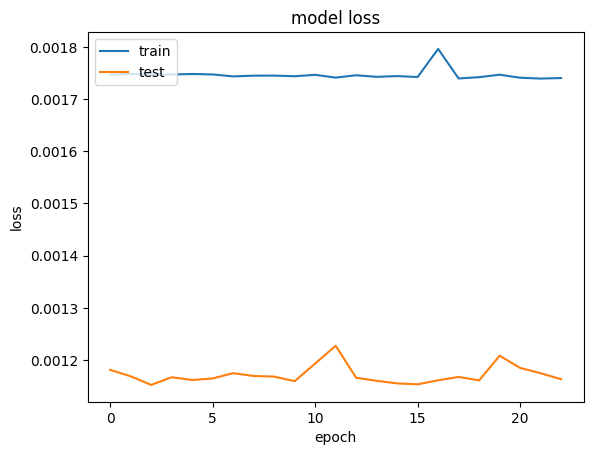

In [ ]:
import matplotlib.pyplot as plt

plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
model.save('GRU.h5')